In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.runtime import setup_runtime

SEED = 42
setup_runtime(SEED)

import json
import pandas as pd
import tensorflow as tf

from src.paths import VISION, ensure_dirs
from src.plots import plot_metric_comparison, plot_training_time_vs_accuracy
from src.vision.data import (
    add_labels,
    class_weights,
    make_scratch_datasets,
    make_transfer_datasets,
    scan_dataset,
    split_dataset,
    split_distribution,
)
from src.vision.eda import (
    dataset_summary,
    show_augmentation_examples,
    show_dataset_eda,
    show_sample_images,
    show_split_distribution,
)
from src.vision.experiments import (
    baseline_experiments,
    comparison,
    deeper_experiments,
    optimizer_experiment,
    registry,
    run_many,
    run_transfer_experiments,
)
from src.vision.inference import (
    predict_unlabeled,
    show_misclassified,
    show_prediction_gallery,
    show_unlabeled_predictions,
)

for path in [
    VISION.processed,
    VISION.figures / "eda",
    VISION.figures / "training_curves",
    VISION.figures / "confusion_matrices",
    VISION.figures / "comparisons",
    VISION.figures / "error_analysis",
    VISION.figures / "inference_examples",
    VISION.tables,
    VISION.histories,
    VISION.models,
    VISION.summaries,
    VISION.predictions,
]:
    ensure_dirs(path)

pd.set_option("display.max_columns", 200)
metadata = {
    "seed": SEED,
    "tensorflow_version": tf.__version__,
    "available_gpus": [device.name for device in tf.config.list_physical_devices("GPU")],
}
(VISION.tables / "environment_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
metadata


{'seed': 42,
 'tensorflow_version': '2.21.0',
 'available_gpus': ['/physical_device:GPU:0']}

## 2. Dataset loading and integrity scan

In [2]:
inventory_df, corrupted_df, unlabeled_df = scan_dataset(VISION.data)

inventory_df.to_csv(VISION.processed / "image_inventory.csv", index=False)
corrupted_df.to_csv(VISION.processed / "corrupted_images.csv", index=False)
unlabeled_df.to_csv(VISION.processed / "unlabeled_inventory.csv", index=False)

summary = dataset_summary(inventory_df, corrupted_df, unlabeled_df)
summary.to_csv(VISION.tables / "dataset_summary.csv", index=False)
summary


,metric,value
0,total_labeled_images,16065
1,total_classes,5
2,corrupted_images,35
3,unlabeled_test_images,10


In [3]:
class_distribution = inventory_df["display_class"].value_counts().sort_index()
class_distribution.to_csv(VISION.tables / "class_distribution.csv", header=["count"])
class_distribution


display_class
Cautions      1671
Crossings     1821
Direction     2961
No Entry      2931
SpeedLimit    6681
Name: count, dtype: int64

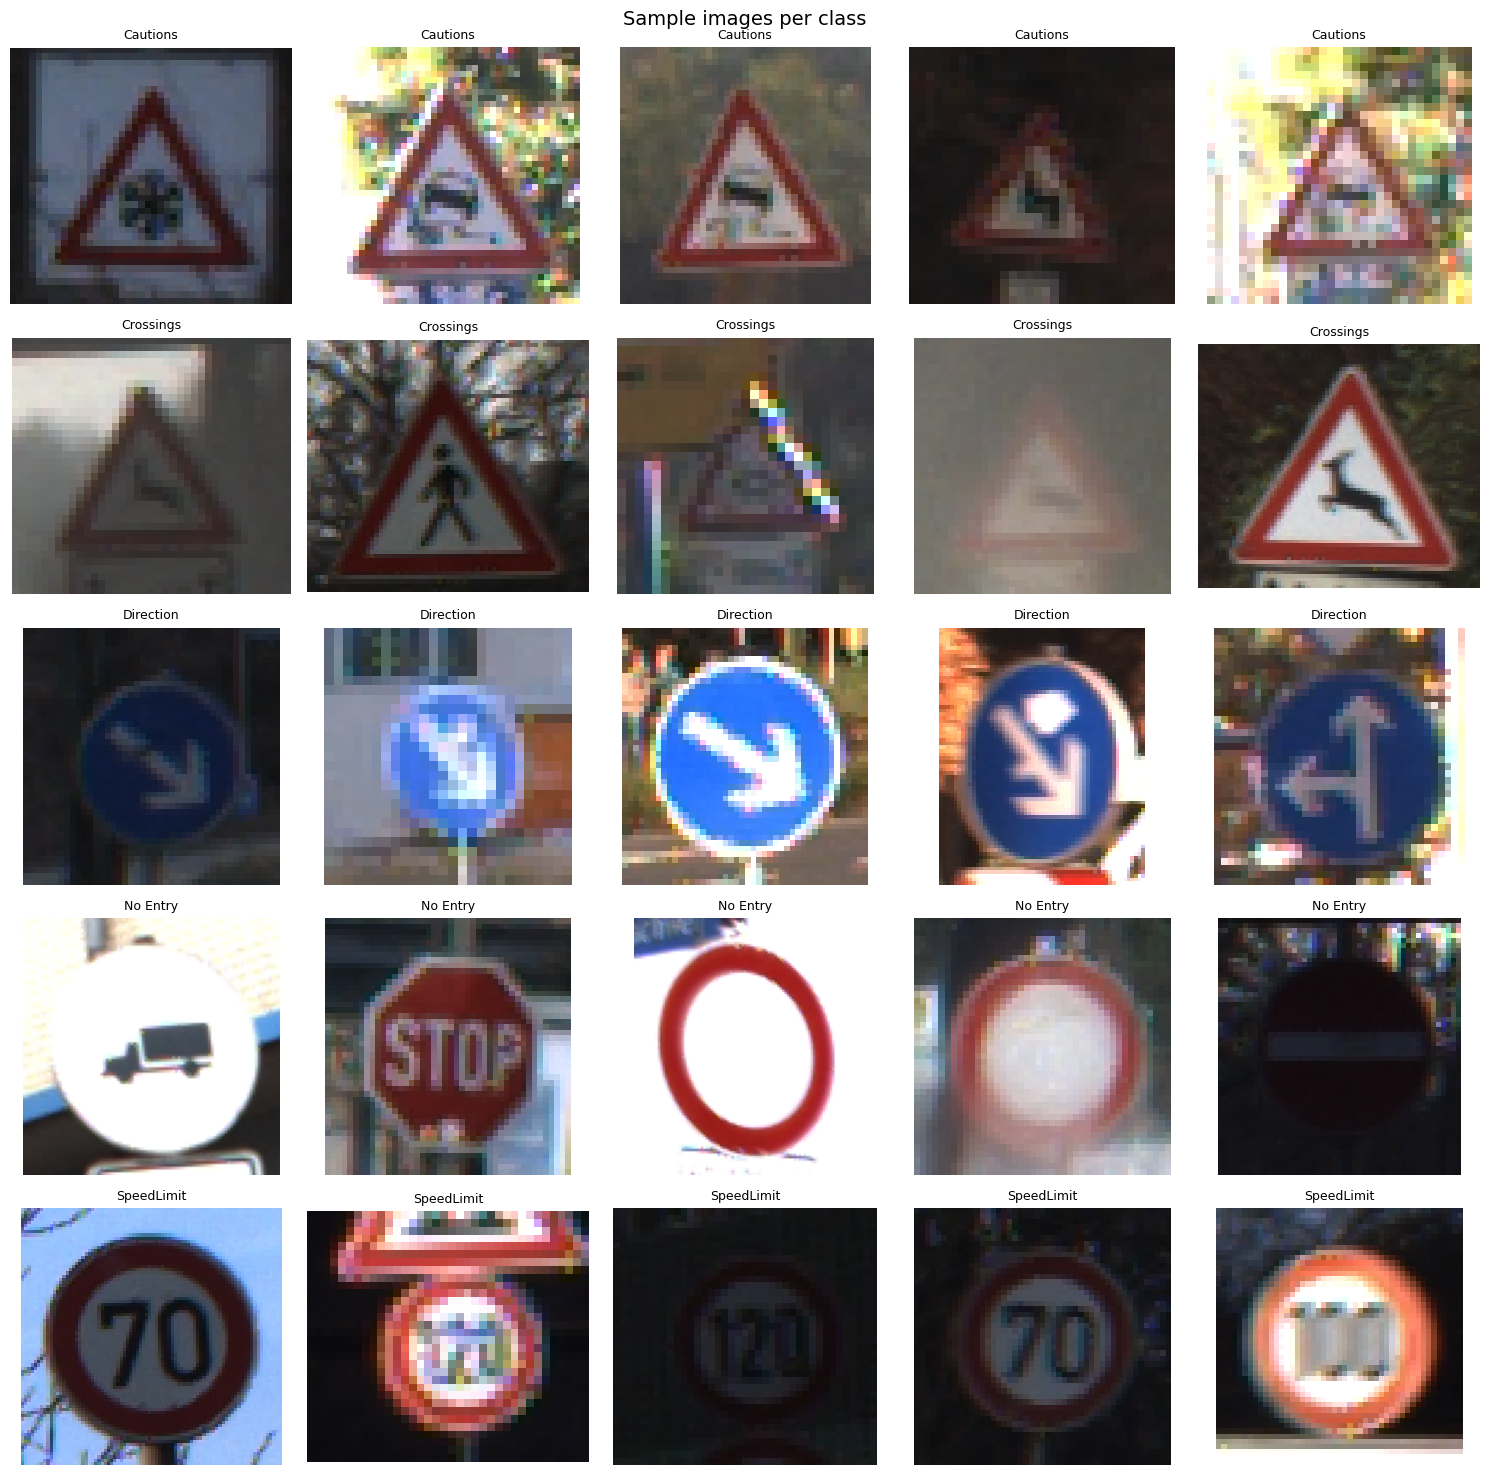

In [4]:
show_sample_images(
    inventory_df,
    seed=SEED,
    path=VISION.figures / "eda" / "sample_images_per_class.png",
)


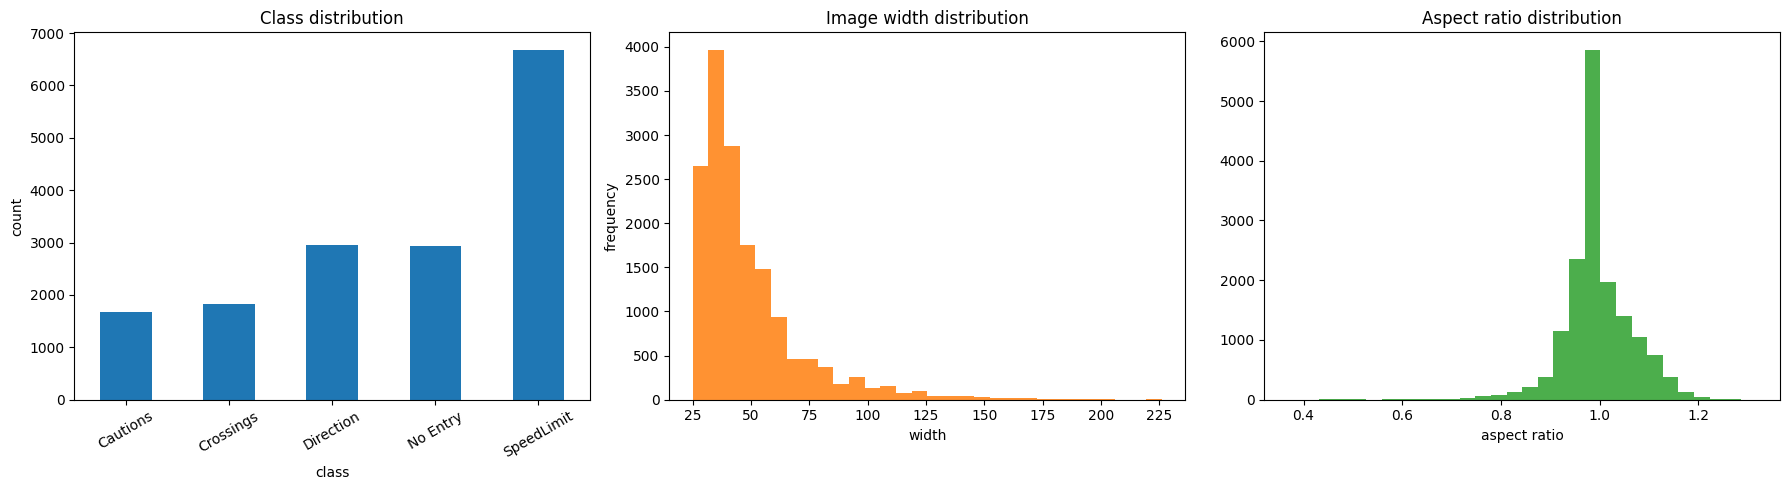

In [5]:
show_dataset_eda(
    inventory_df,
    path=VISION.figures / "eda" / "dataset_eda_summary.png",
)


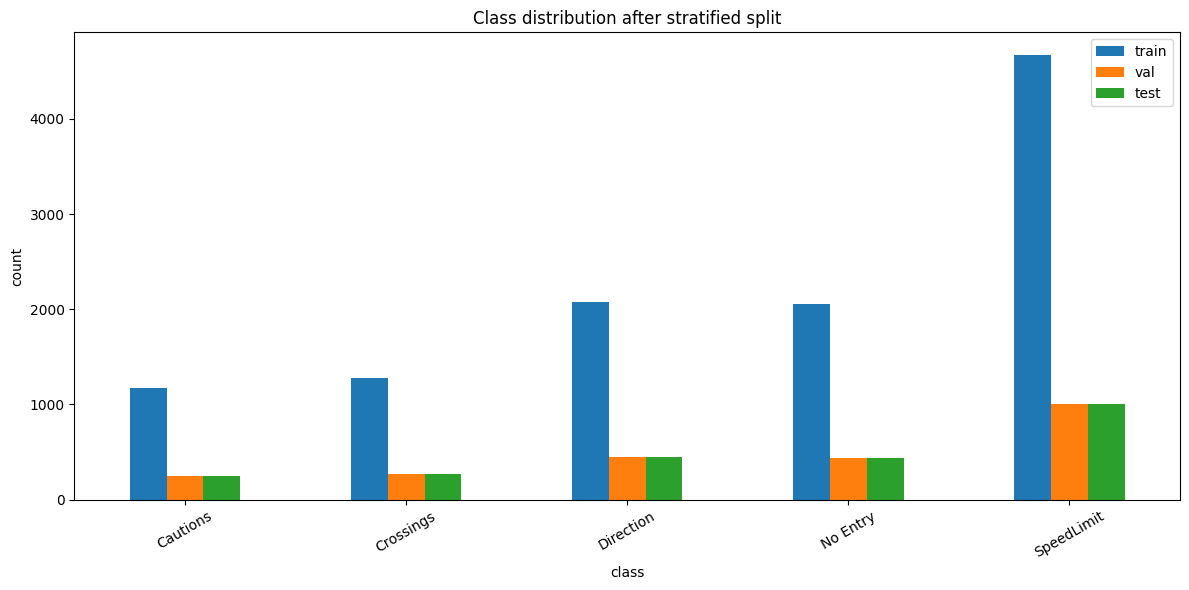

,train,val,test
display_class,,,
Cautions,1170,250,251
Crossings,1275,273,273
Direction,2072,445,444
No Entry,2052,439,440
SpeedLimit,4676,1003,1002


In [6]:
train_df, val_df, test_df = split_dataset(inventory_df, seed=SEED)
[train_df, val_df, test_df], label_names, label_to_id, id_to_label = add_labels(train_df, val_df, test_df)

train_df.to_csv(VISION.processed / "split_train.csv", index=False)
val_df.to_csv(VISION.processed / "split_val.csv", index=False)
test_df.to_csv(VISION.processed / "split_test.csv", index=False)
(VISION.tables / "label_map.json").write_text(json.dumps(label_to_id, indent=2), encoding="utf-8")

splits = split_distribution(train_df, val_df, test_df)
splits.to_csv(VISION.tables / "split_distribution.csv")
show_split_distribution(splits, VISION.figures / "eda" / "split_distribution.png")
splits


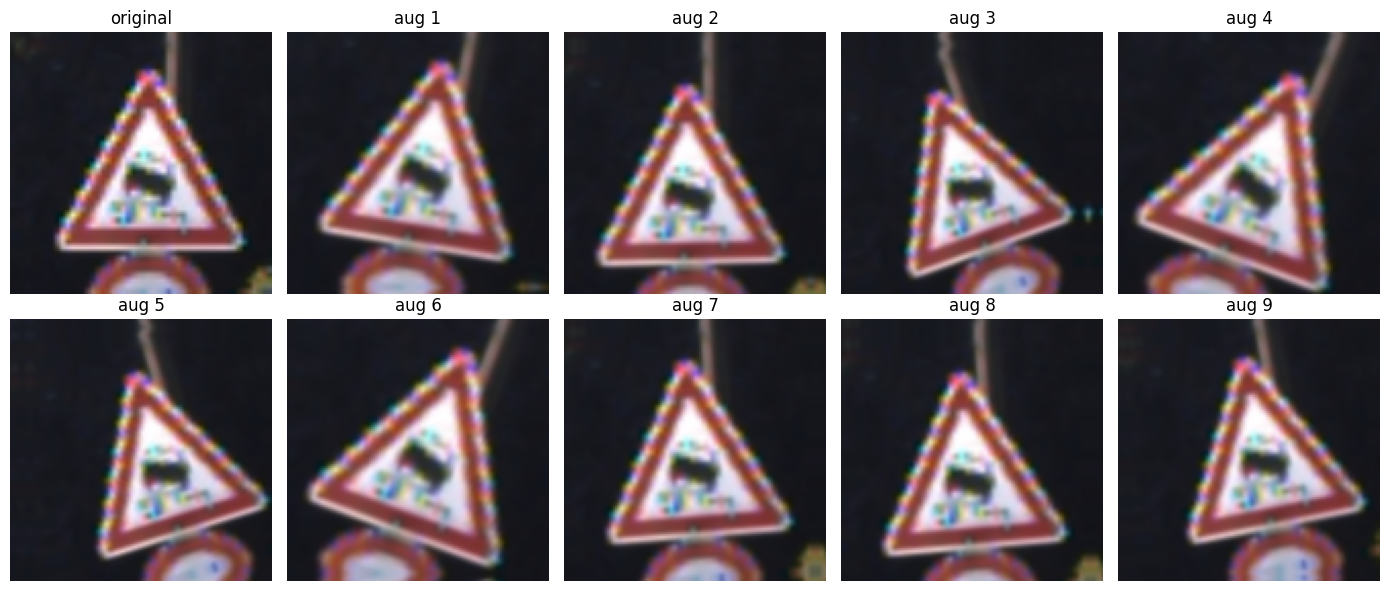

{0: 1.9222222222222223,
 1: 1.763921568627451,
 2: 1.0854247104247103,
 3: 1.0960038986354776,
 4: 0.48096663815226687}

In [7]:
augmentation = show_augmentation_examples(
    train_df,
    class_name=label_names[0],
    seed=SEED,
    path=VISION.figures / "eda" / "augmentation_examples.png",
)

scratch_datasets = make_scratch_datasets(train_df, val_df, test_df, seed=SEED)
transfer_datasets = make_transfer_datasets(train_df, val_df, test_df, seed=SEED)
datasets = {"scratch": scratch_datasets, "transfer": transfer_datasets}

class_weight_dict = class_weights(train_df)
class_weight_dict


## 4. Baseline CNN experiments

The baseline family tests the required scratch CNN, the same model with augmentation, and the same model with class weights.


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.8402 - loss: 0.3725 - val_accuracy: 0.9257 - val_loss: 0.2011
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9627 - loss: 0.0972 - val_accuracy: 0.9606 - val_loss: 0.1053
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9820 - loss: 0.0538 - val_accuracy: 0.9793 - val_loss: 0.0632
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9900 - loss: 0.0308 - val_accuracy: 0.9892 - val_loss: 0.0467
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9884 - loss: 0.0361 - val_accuracy: 0.9892 - val_loss: 0.0399
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9946 - loss: 0.0173 - val_accuracy: 0.9946 - val_loss: 0.0235
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9980 - loss: 0.0059 - val_accuracy: 0.9946 - val_loss: 0.0216
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9956 - loss: 0.0127 - 

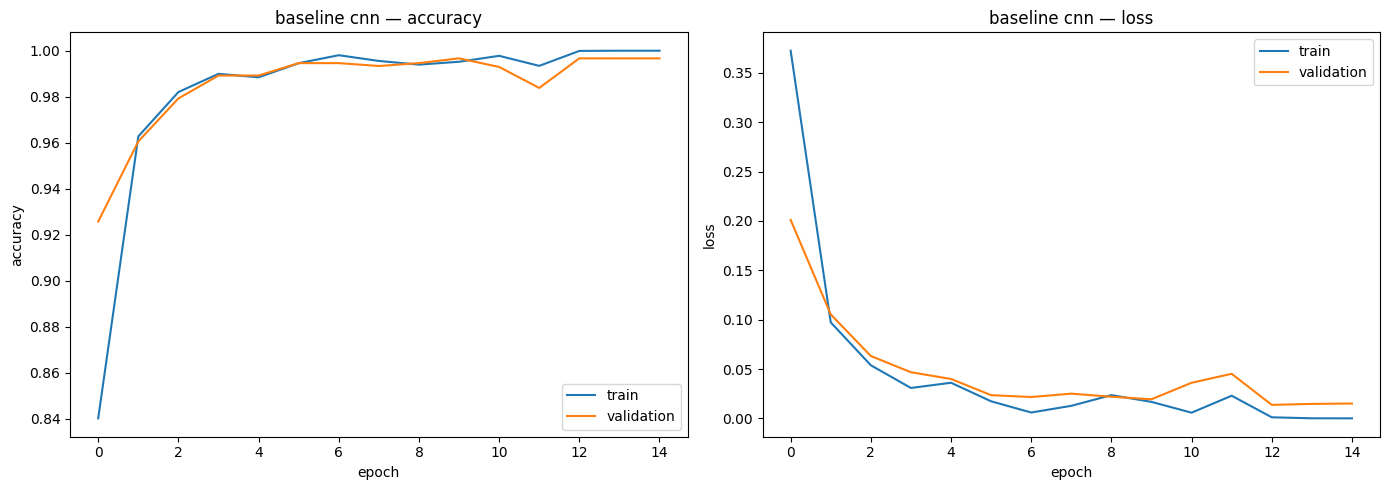

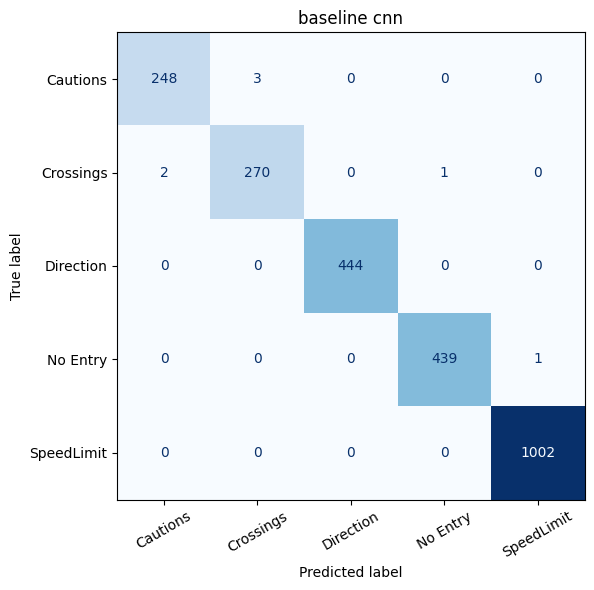

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7871 - loss: 0.4901 - val_accuracy: 0.8697 - val_loss: 0.2840
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8896 - loss: 0.2379 - val_accuracy: 0.9378 - val_loss: 0.1306
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9474 - loss: 0.1268 - val_accuracy: 0.9606 - val_loss: 0.0943
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9665 - loss: 0.0891 - val_accuracy: 0.9909 - val_loss: 0.0352
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9781 - loss: 0.0570 - val_accuracy: 0.9967 - val_loss: 0.0142
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9813 - loss: 0.0509 - val_accuracy: 0.9793 - val_loss: 0.0612
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9789 - loss: 0.0576 - val_accuracy: 0.9917 - val_loss: 0.0219
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9908 - loss: 0.0280 - 

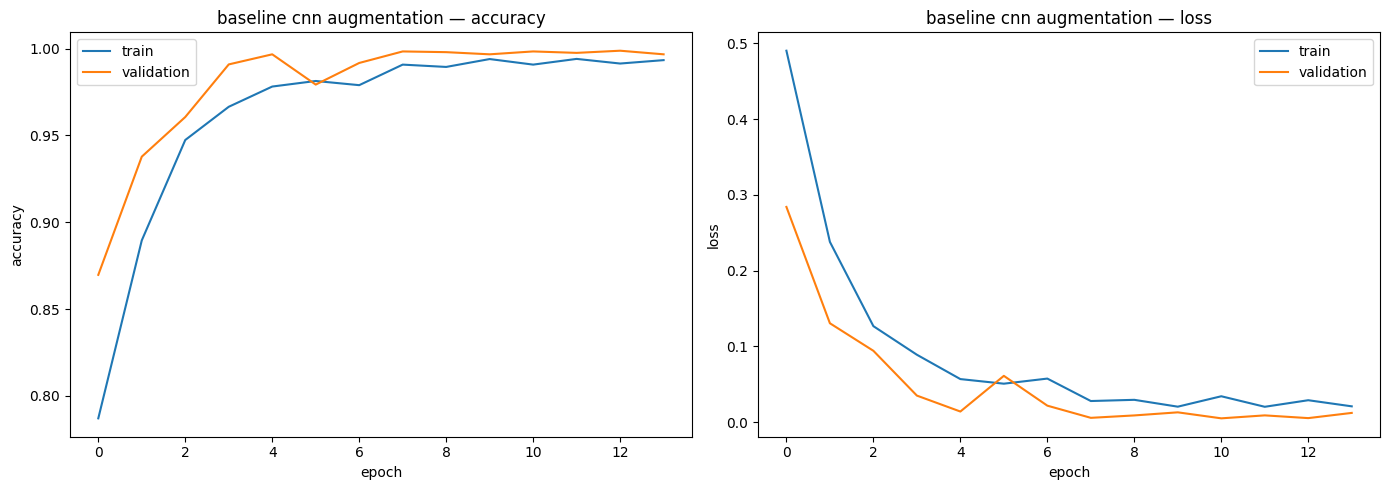

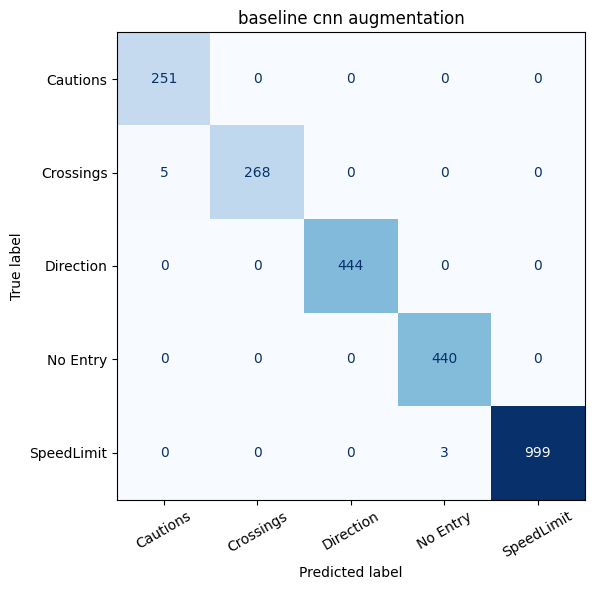

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8135 - loss: 0.4787 - val_accuracy: 0.9485 - val_loss: 0.1507
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9635 - loss: 0.1355 - val_accuracy: 0.9846 - val_loss: 0.0456
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9805 - loss: 0.0727 - val_accuracy: 0.9888 - val_loss: 0.0393
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9932 - loss: 0.0287 - val_accuracy: 0.9917 - val_loss: 0.0343
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9942 - loss: 0.0227 - val_accuracy: 0.9950 - val_loss: 0.0190
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9902 - loss: 0.0368 - val_accuracy: 0.9959 - val_loss: 0.0154
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9928 - loss: 0.0387 - val_accuracy: 0.9581 - val_loss: 0.1246
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9959 - loss: 0.0140 - 

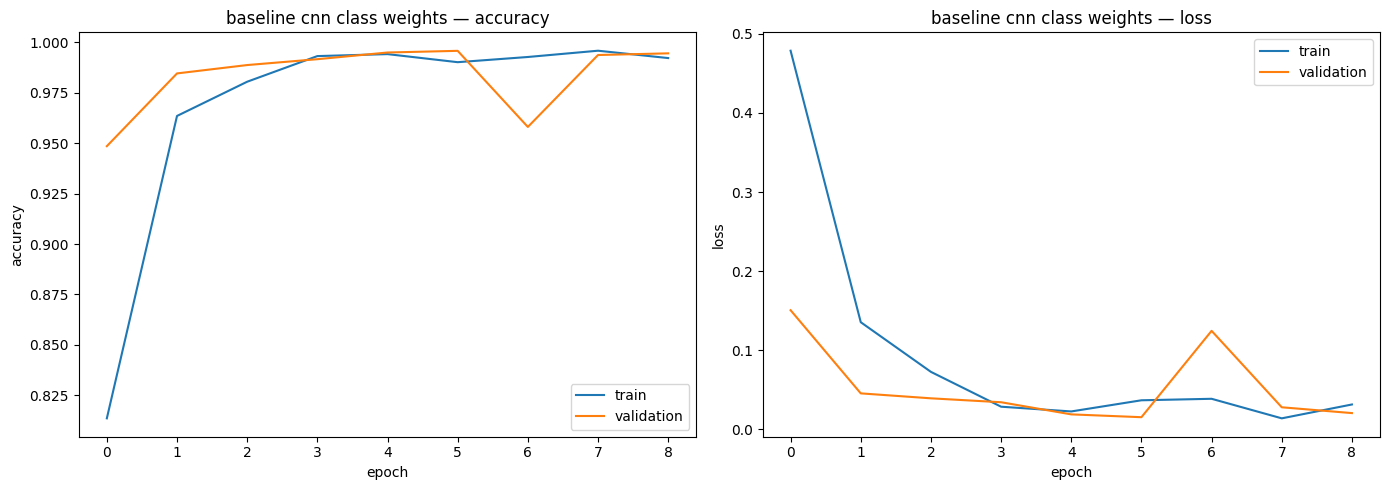

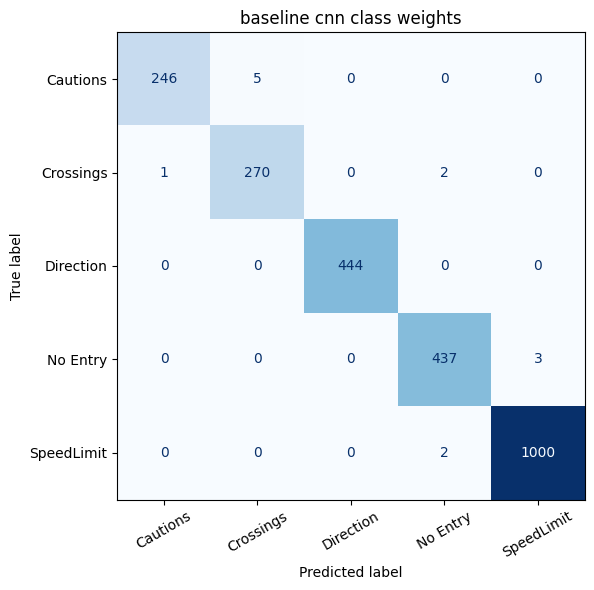

,accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,experiment_name,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters,optimizer,learning_rate,model_path
0,0.997095,0.008551,0.995548,0.994957,0.995252,0.997093,7,baseline_cnn,15,151.322505,8523589,0,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...
1,0.996680,0.012843,0.994739,0.995738,0.995200,0.996682,8,baseline_cnn_augmentation,14,145.215450,8523589,0,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...
2,0.994606,0.027363,0.993142,0.992055,0.992583,0.994604,13,baseline_cnn_class_weights,9,89.468072,8523589,0,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...


In [8]:
vision_results = {}
baseline_names = [experiment.name for experiment in baseline_experiments(len(label_names), augmentation, class_weight_dict)]
vision_results.update(run_many(
    baseline_experiments(len(label_names), augmentation, class_weight_dict),
    datasets=datasets,
    test_df=test_df,
    labels=label_names,
    outputs=VISION,
))

baseline_table = comparison(vision_results, baseline_names, VISION.tables / "baseline_comparison.csv")
baseline_table


## 5. Deeper CNN ablation study



Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7858 - loss: 0.5099 - val_accuracy: 0.8539 - val_loss: 0.3032
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.8533 - loss: 0.3066 - val_accuracy: 0.9178 - val_loss: 0.2026
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.8976 - loss: 0.2187 - val_accuracy: 0.9328 - val_loss: 0.1481
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9298 - loss: 0.1622 - val_accuracy: 0.9705 - val_loss: 0.0812
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9553 - loss: 0.1126 - val_accuracy: 0.9871 - val_loss: 0.0422
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9651 - loss: 0.0925 - val_accuracy: 0.9863 - val_loss: 0.0442
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9783 - loss: 0.0602 - val_accuracy: 0.9934 - val_loss: 0.0192
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.9850 - loss: 0.0429 - 

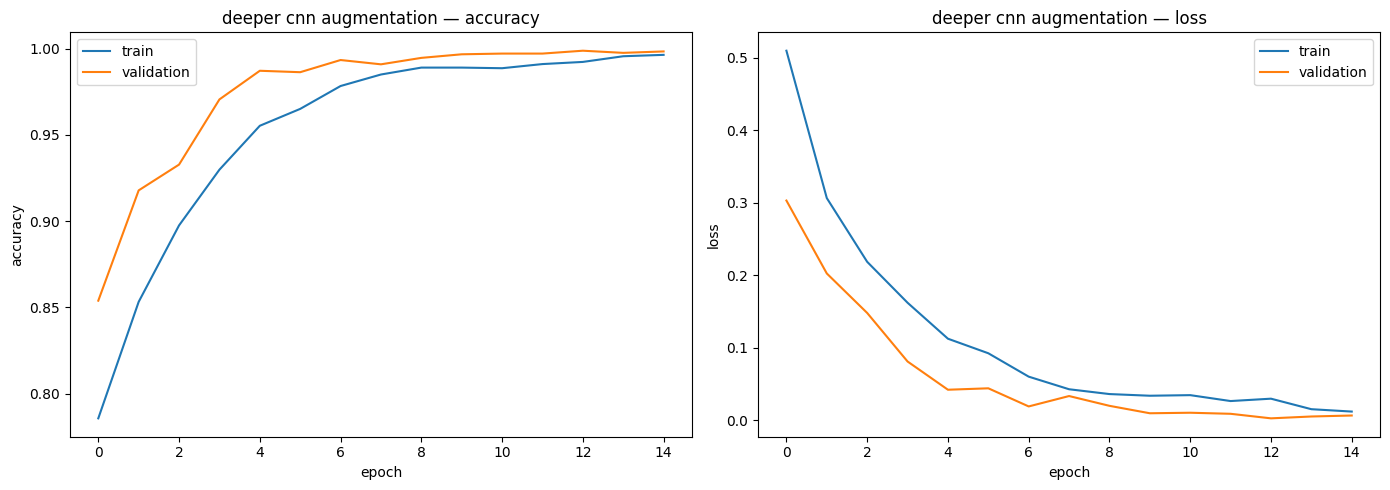

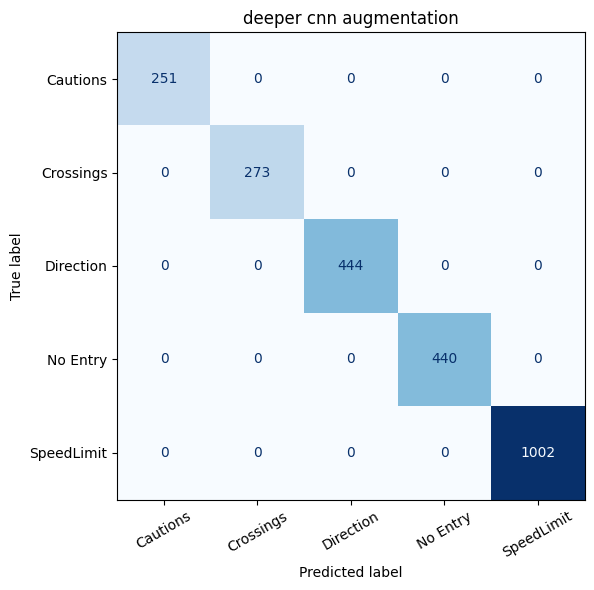

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - accuracy: 0.7247 - loss: 0.8242 - val_accuracy: 0.7398 - val_loss: 0.6502
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.8557 - loss: 0.3483 - val_accuracy: 0.8917 - val_loss: 0.2660
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.8992 - loss: 0.2582 - val_accuracy: 0.9618 - val_loss: 0.1124
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9433 - loss: 0.1526 - val_accuracy: 0.9544 - val_loss: 0.1048
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.9617 - loss: 0.1133 - val_accuracy: 0.9718 - val_loss: 0.0964
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9586 - loss: 0.1253 - val_accuracy: 0.9564 - val_loss: 0.1240
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.9803 - loss: 0.0564 - val_accuracy: 0.9967 - val_loss: 0.0161
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9846 - loss: 0

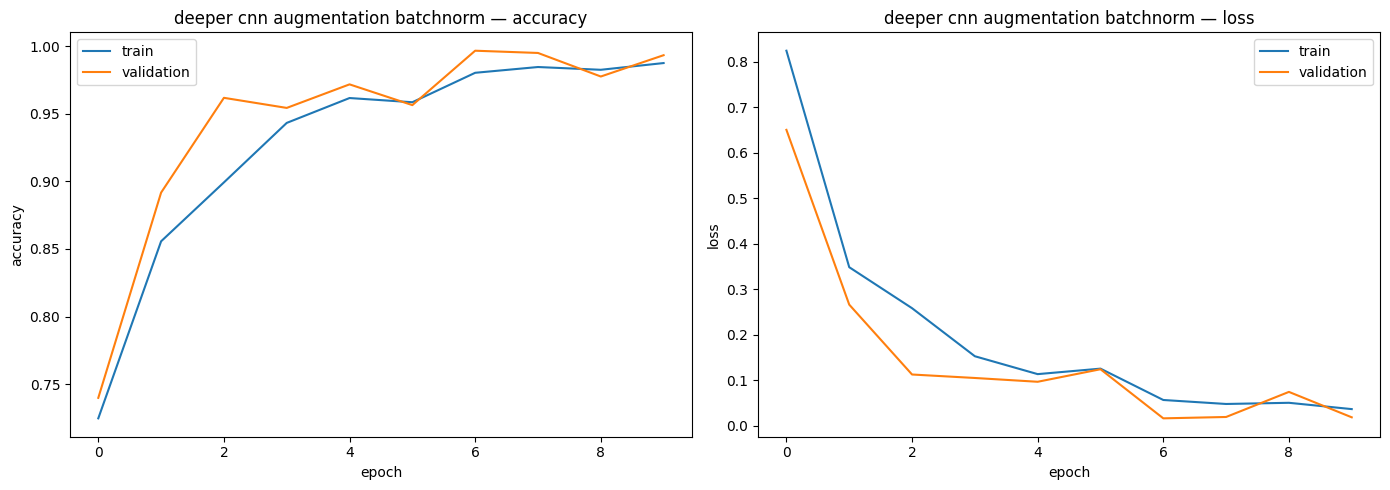

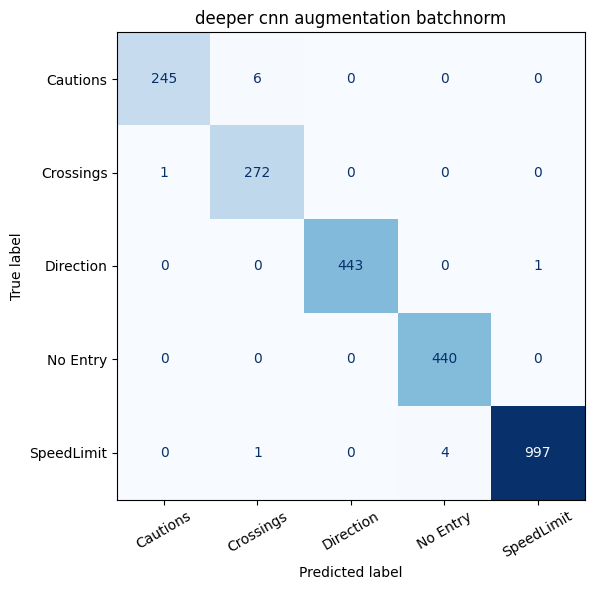

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.7148 - loss: 0.6944 - val_accuracy: 0.8444 - val_loss: 0.3130
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8278 - loss: 0.3674 - val_accuracy: 0.8394 - val_loss: 0.3054
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8340 - loss: 0.3323 - val_accuracy: 0.8465 - val_loss: 0.2848
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8702 - loss: 0.2767 - val_accuracy: 0.9145 - val_loss: 0.1842
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.8994 - loss: 0.2234 - val_accuracy: 0.9531 - val_loss: 0.1461
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9295 - loss: 0.1648 - val_accuracy: 0.9402 - val_loss: 0.1278
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9471 - loss: 0.1303 - val_accuracy: 0.9743 - val_loss: 0.0652
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9544 - loss: 0.1194 - 

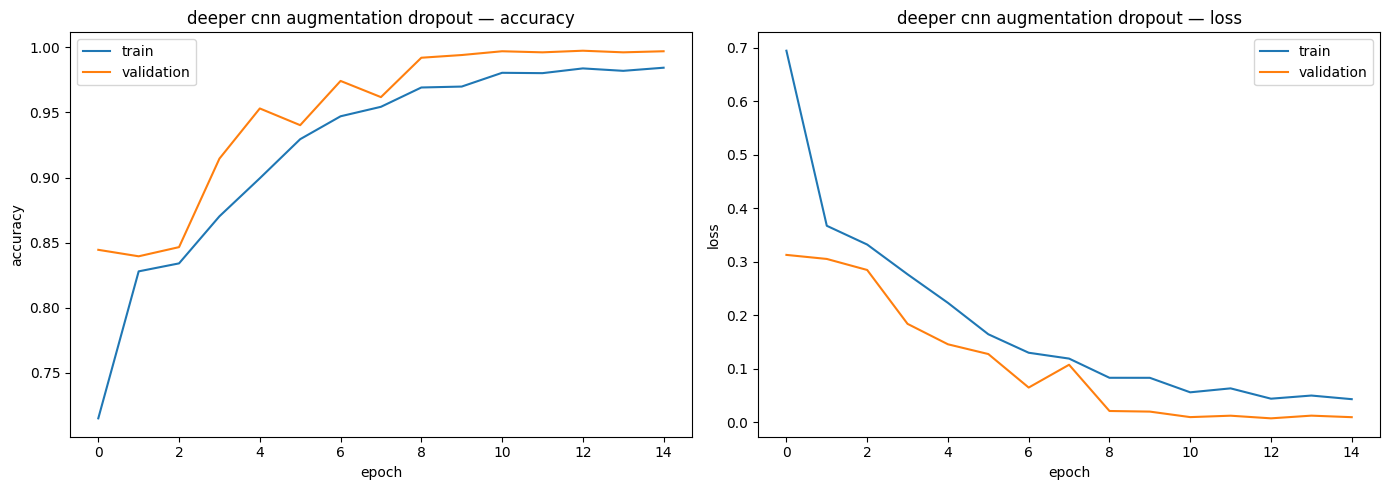

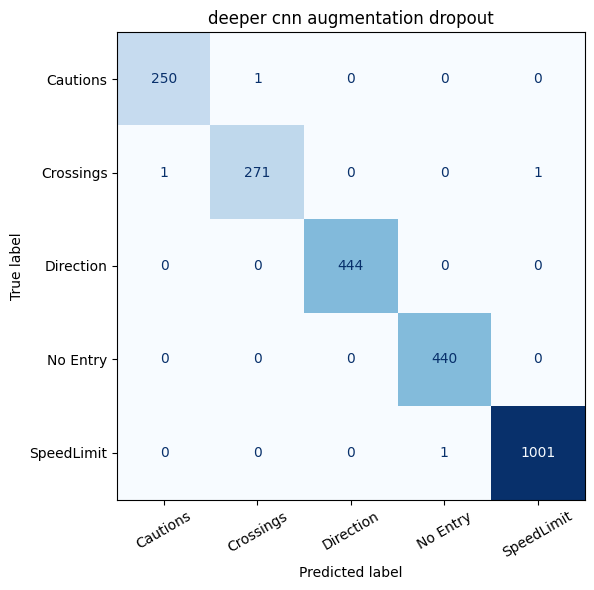

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 40s 104ms/step - accuracy: 0.6322 - loss: 1.2041 - val_accuracy: 0.5813 - val_loss: 1.0195
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.7867 - loss: 0.5031 - val_accuracy: 0.8328 - val_loss: 0.3276
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.7950 - loss: 0.4533 - val_accuracy: 0.8365 - val_loss: 0.3106
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.8028 - loss: 0.4323 - val_accuracy: 0.8266 - val_loss: 0.3660
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.8025 - loss: 0.4192 - val_accuracy: 0.8344 - val_loss: 0.3292
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.8161 - loss: 0.3687 - val_accuracy: 0.8349 - val_loss: 0.2832
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.8233 - loss: 0.3384 - val_accuracy: 0.8622 - val_loss: 0.2426
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.8436 - loss: 0

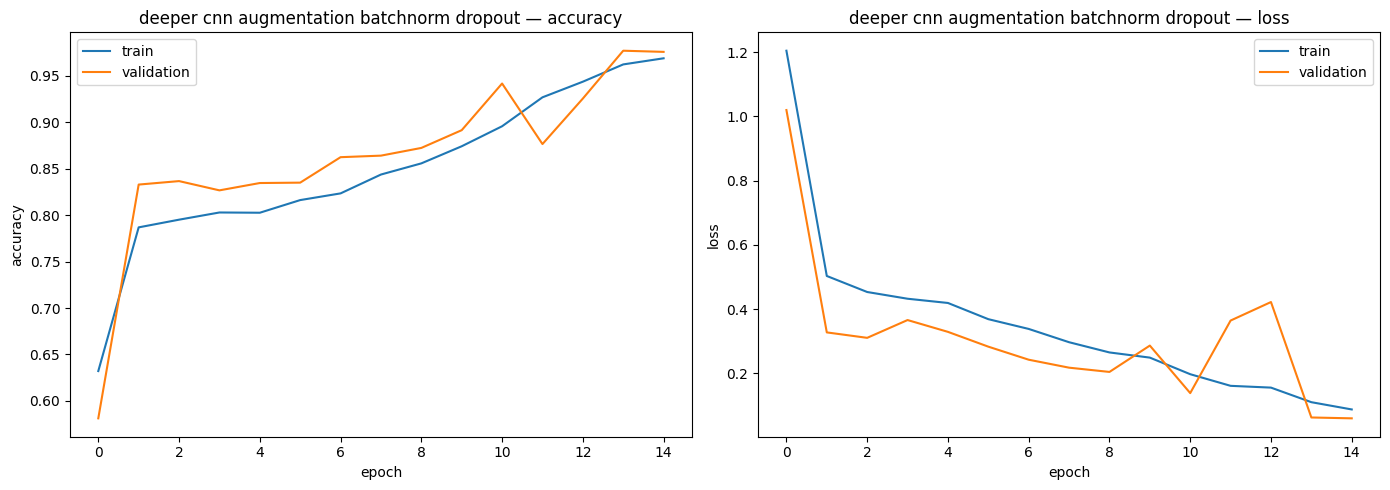

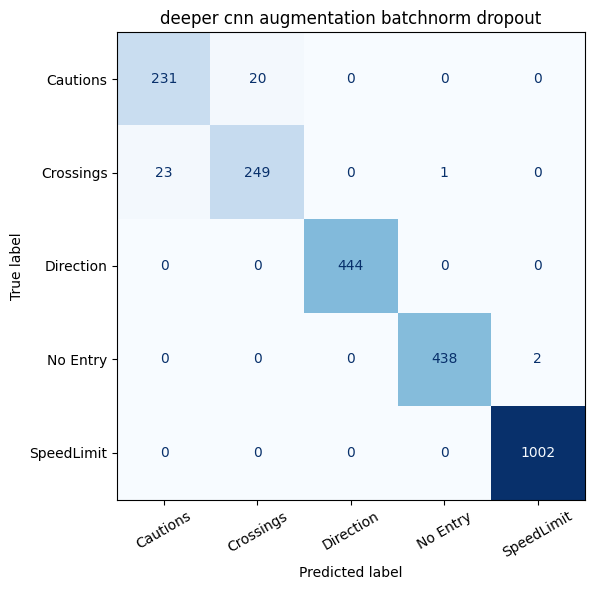

,accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,experiment_name,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters,optimizer,learning_rate,model_path
0,1.000000,0.001224,1.000000,1.000000,1.000000,1.000000,0,deeper_cnn_augmentation,15,270.613568,8717349,0,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...
1,0.998340,0.005224,0.997815,0.997538,0.997676,0.998339,4,deeper_cnn_augmentation_dropout,15,315.326496,8717349,0,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...
2,0.994606,0.018152,0.992167,0.993038,0.992554,0.994610,13,deeper_cnn_augmentation_batchnorm,10,378.340737,8718245,896,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...
3,0.980913,0.051547,0.966166,0.965572,0.965852,0.980898,46,deeper_cnn_augmentation_batchnorm_dropout,15,556.530417,8718245,896,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...


In [9]:
deeper_names = [experiment.name for experiment in deeper_experiments(len(label_names), augmentation)]
vision_results.update(run_many(
    deeper_experiments(len(label_names), augmentation),
    datasets=datasets,
    test_df=test_df,
    labels=label_names,
    outputs=VISION,
))

deeper_table = comparison(vision_results, deeper_names, VISION.tables / "deeper_comparison.csv")
deeper_table


## 6. Optimizer comparison: Adam vs SGD + momentum

The optimizer trial holds the deeper batch-normalization-plus-dropout architecture fixed and changes only the optimizer.


Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 36s 96ms/step - accuracy: 0.4097 - loss: 1.5258 - val_accuracy: 0.4162 - val_loss: 1.4691
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.4157 - loss: 1.4699 - val_accuracy: 0.4162 - val_loss: 1.4690
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.4158 - loss: 1.4702 - val_accuracy: 0.4162 - val_loss: 1.4691
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.4158 - loss: 1.4699 - val_accuracy: 0.4162 - val_loss: 1.4690
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.4158 - loss: 1.4698 - val_accuracy: 0.4162 - val_loss: 1.4690
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.4158 - loss: 1.4703 - val_accuracy: 0.4162 - val_loss: 1.4692
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.4158 - loss: 1.4698 - val_accuracy: 0.4162 - val_loss: 1.4695


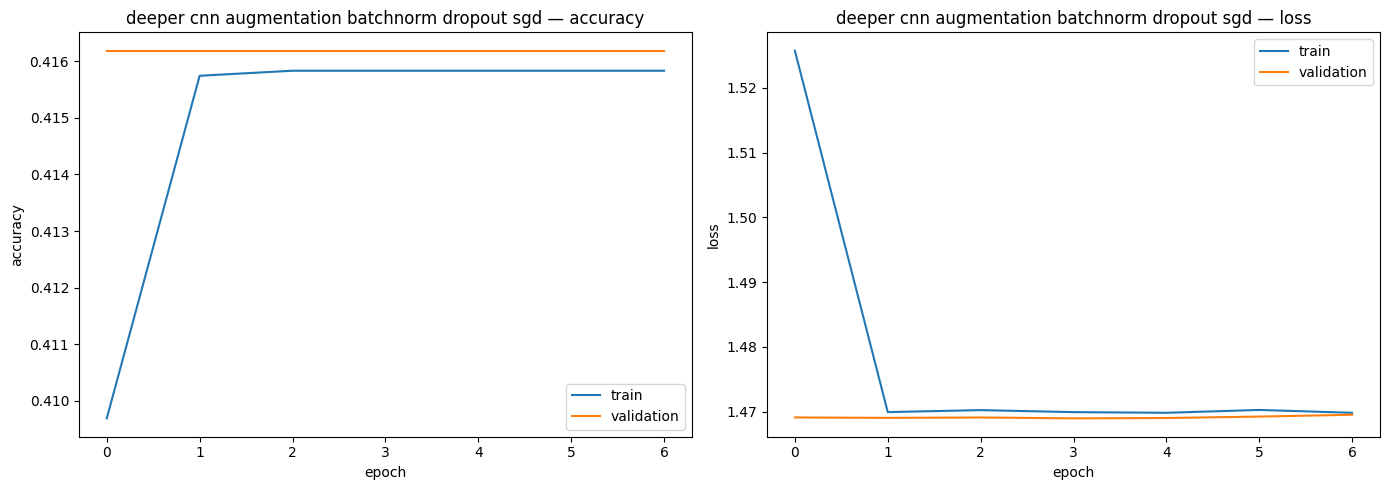

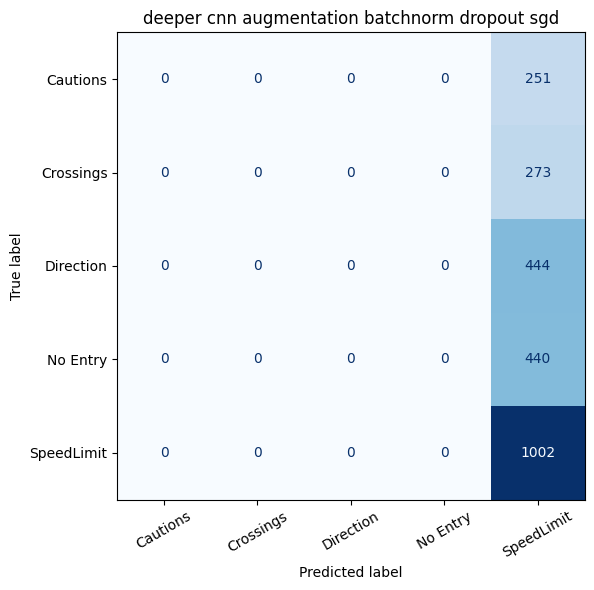

,accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,experiment_name,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters,optimizer,learning_rate,model_path
0,0.980913,0.051547,0.966166,0.965572,0.965852,0.980898,46,deeper_cnn_augmentation_batchnorm_dropout,15,556.530417,8718245,896,Adam,0.001,/home/wizard/Projects/school/AI/submissions/su...
1,0.415768,1.469542,0.083154,0.200000,0.117468,0.244196,1408,deeper_cnn_augmentation_batchnorm_dropout_sgd,7,241.500985,8718245,896,SGD,0.010,/home/wizard/Projects/school/AI/submissions/su...


In [10]:
sgd_experiment = optimizer_experiment(len(label_names), augmentation)
vision_results.update(run_many(
    [sgd_experiment],
    datasets=datasets,
    test_df=test_df,
    labels=label_names,
    outputs=VISION,
))

optimizer_table = comparison(
    vision_results,
    ["deeper_cnn_augmentation_batchnorm_dropout", "deeper_cnn_augmentation_batchnorm_dropout_sgd"],
    VISION.tables / "optimizer_comparison.csv",
)
optimizer_table


## 7. Transfer learning with MobileNetV2


Epoch 1/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.9398 - loss: 0.1576 - val_accuracy: 0.9730 - val_loss: 0.0627
Epoch 2/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9762 - loss: 0.0648 - val_accuracy: 0.9809 - val_loss: 0.0463
Epoch 3/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9837 - loss: 0.0442 - val_accuracy: 0.9755 - val_loss: 0.0558
Epoch 4/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9854 - loss: 0.0404 - val_accuracy: 0.9876 - val_loss: 0.0406
Epoch 5/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9843 - loss: 0.0440 - val_accuracy: 0.9888 - val_loss: 0.0262
Epoch 6/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9899 - loss: 0.0261 - val_accuracy: 0.9880 - val_loss: 0.0313
Epoch 7/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9903 - loss: 0.0255 - val_accuracy: 0.9946 - val_loss: 0.0160
Epoch 8/12
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9888 - loss: 0.0354 - 

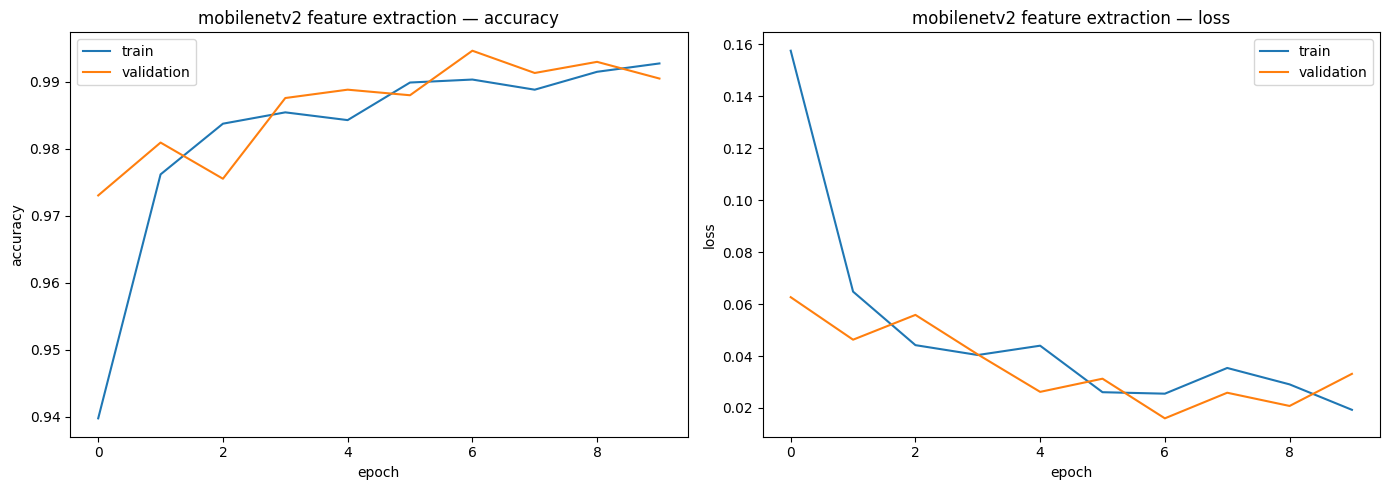

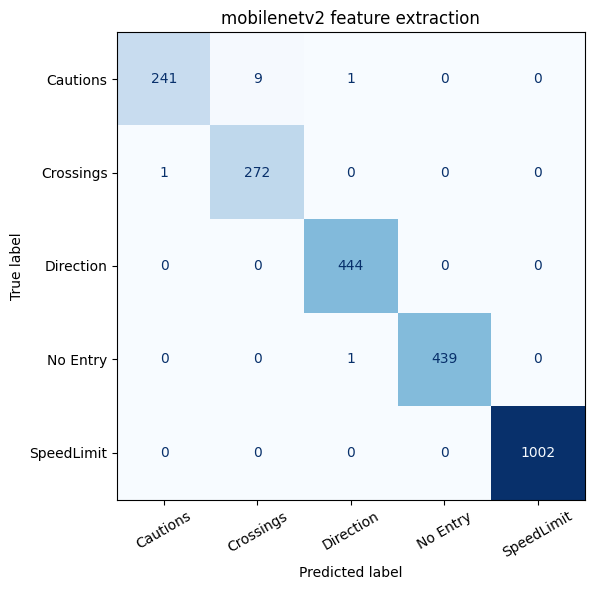

Epoch 1/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.9940 - loss: 0.0179 - val_accuracy: 0.9905 - val_loss: 0.0257
Epoch 2/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9986 - loss: 0.0052 - val_accuracy: 0.9988 - val_loss: 0.0052
Epoch 3/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9980 - loss: 0.0071 - val_accuracy: 0.9967 - val_loss: 0.0096
Epoch 4/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9990 - loss: 0.0028 - val_accuracy: 0.9946 - val_loss: 0.0195
Epoch 5/8
703/703 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9993 - loss: 0.0021 - val_accuracy: 0.9938 - val_loss: 0.0174


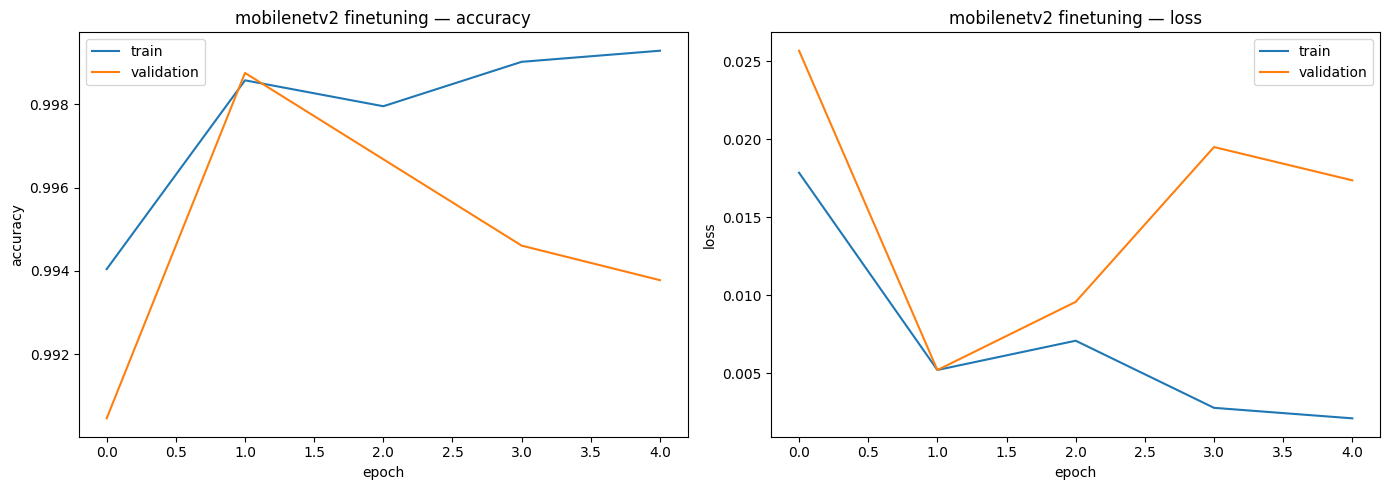

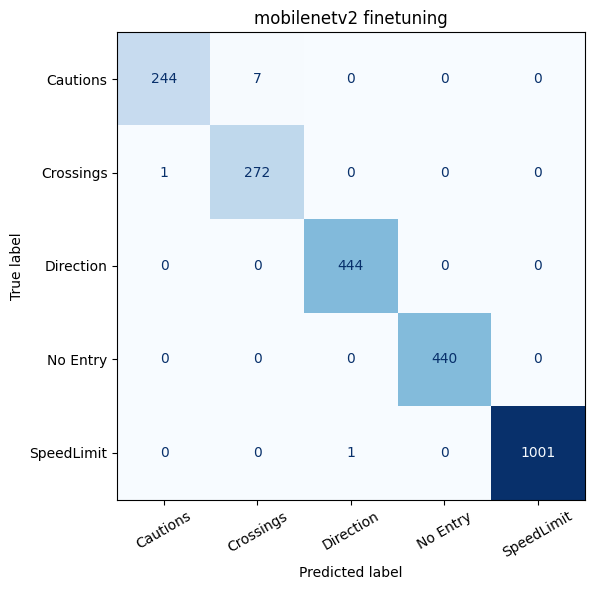

,accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_f1,misclassified_samples,experiment_name,epochs_trained,training_time_seconds,trainable_parameters,non_trainable_parameters,optimizer,learning_rate,model_path
0,0.996266,0.008429,0.993716,0.993490,0.993551,0.996264,9,mobilenetv2_finetuning,5,132.496796,1677701,909504,Adam,0.00001,/home/wizard/Projects/school/AI/submissions/su...
1,0.995021,0.015034,0.991871,0.990845,0.991250,0.995010,12,mobilenetv2_feature_extraction,10,231.124725,329221,2257984,Adam,0.00100,/home/wizard/Projects/school/AI/submissions/su...


In [11]:
transfer_results = run_transfer_experiments(
    datasets=datasets,
    test_df=test_df,
    labels=label_names,
    outputs=VISION,
)
vision_results.update(transfer_results)

transfer_table = comparison(
    vision_results,
    ["mobilenetv2_feature_extraction", "mobilenetv2_finetuning"],
    VISION.tables / "transfer_learning_comparison.csv",
)
transfer_table


## 9. Error analysis and inference gallery


Best overall experiment: deeper_cnn_augmentation
Qualitative inference model: mobilenetv2_finetuning


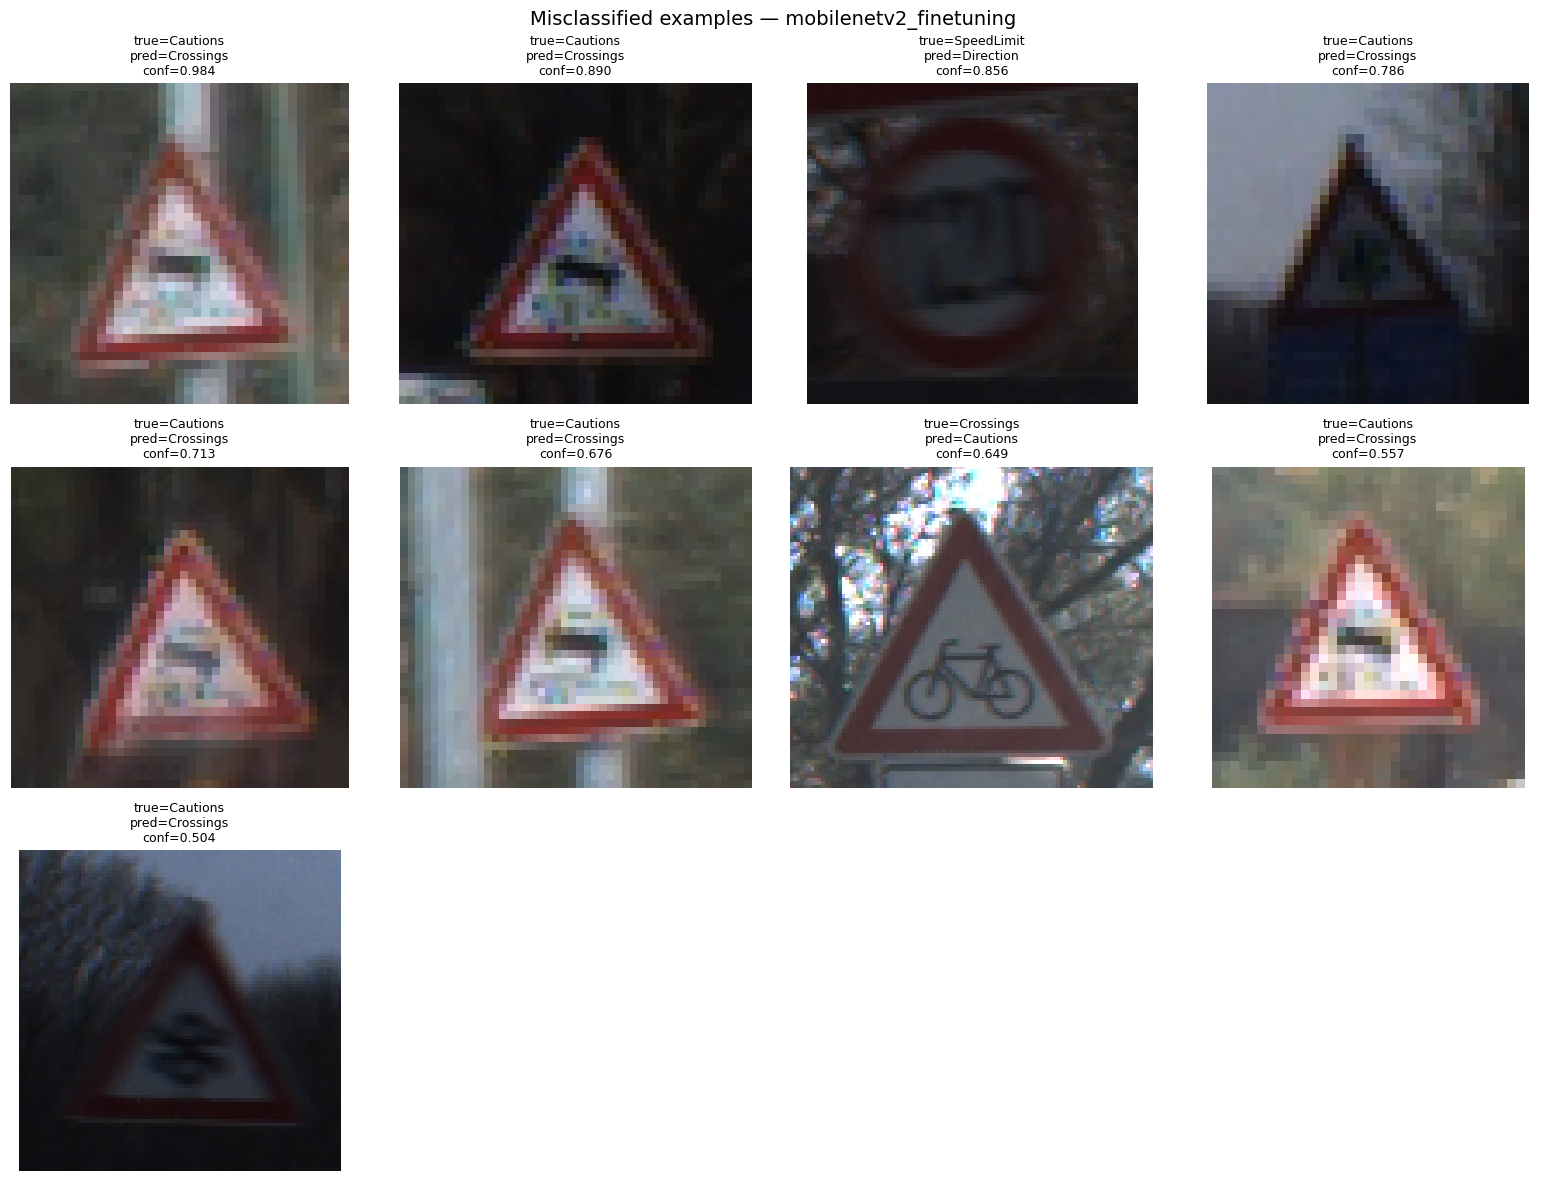

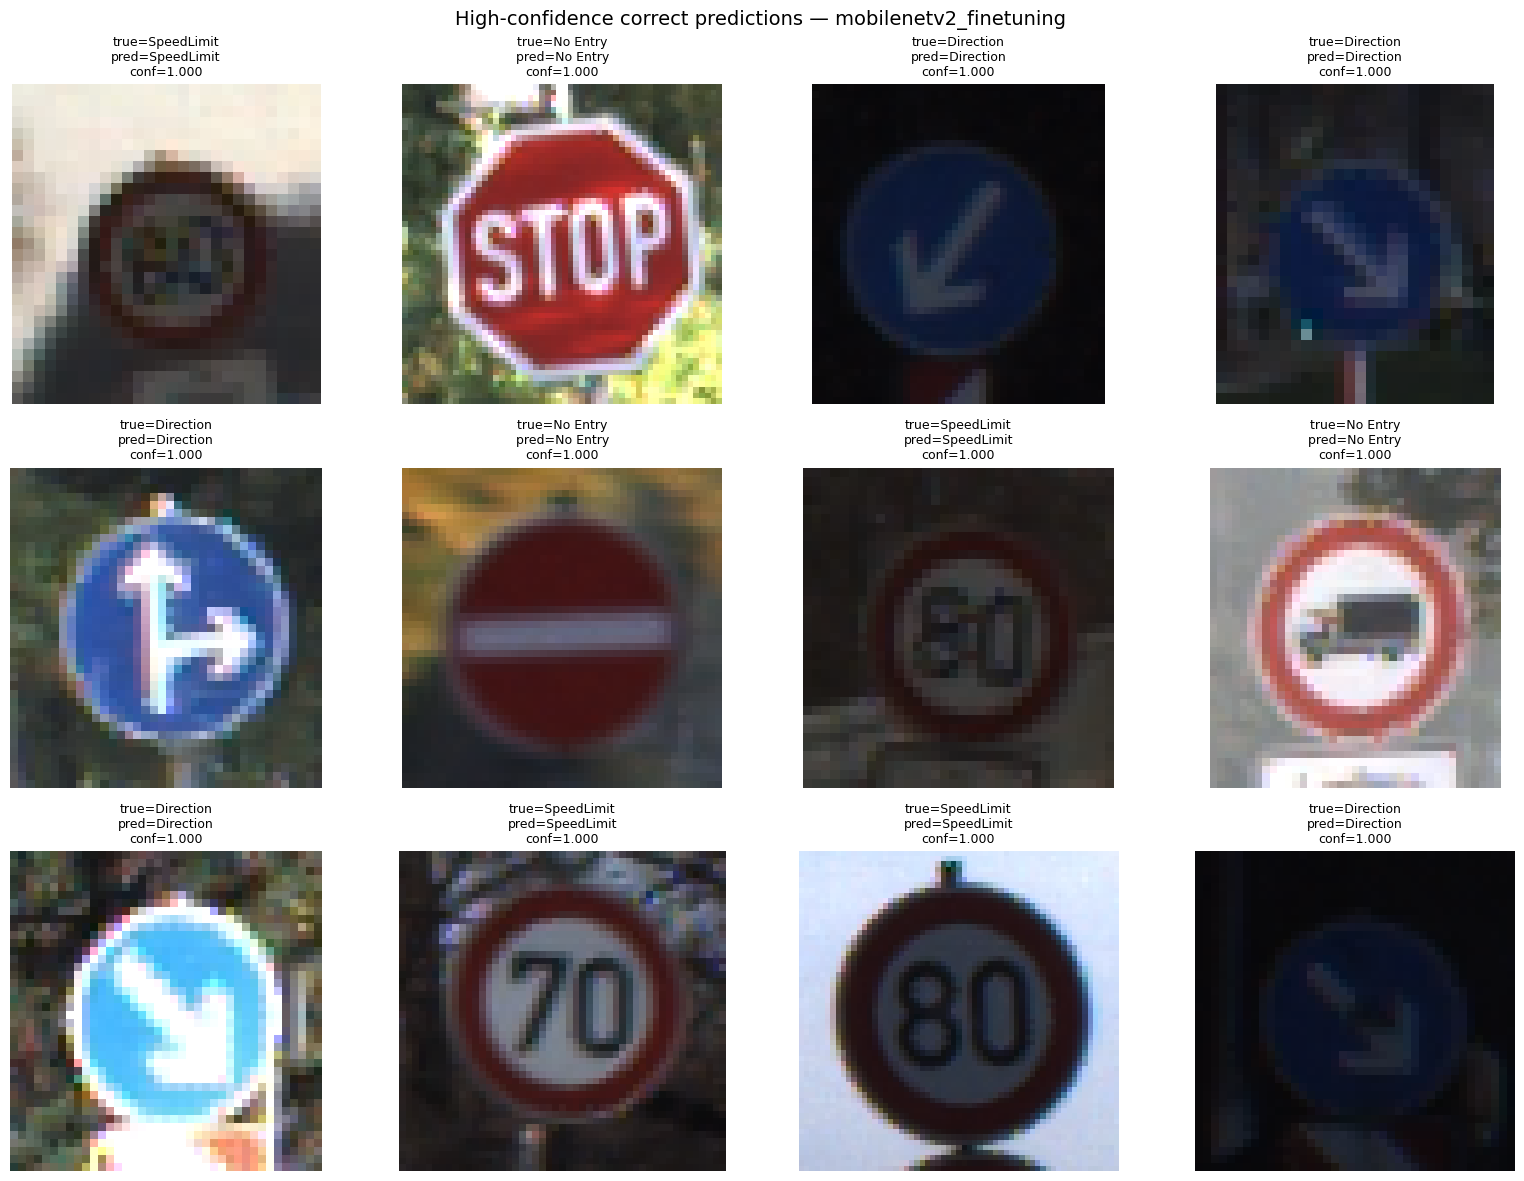

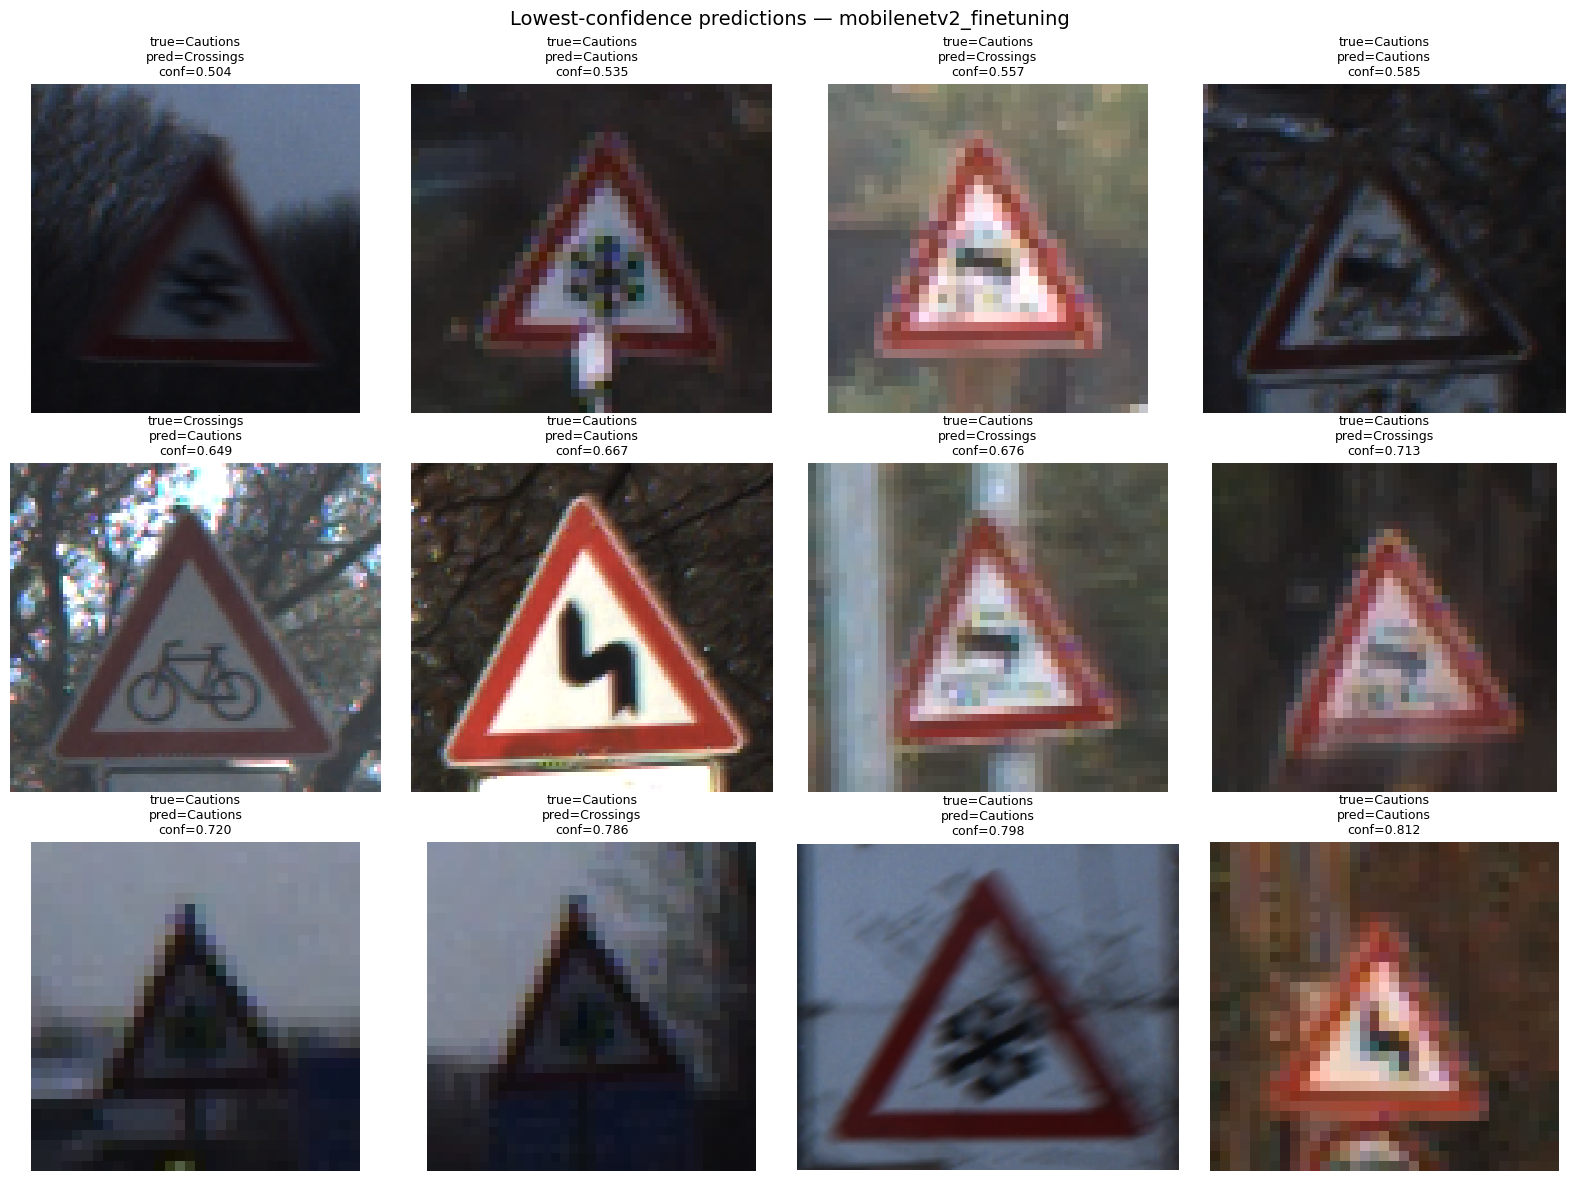

In [13]:
best_name = vision_registry.iloc[0]["experiment_name"]
qualitative_name = "mobilenetv2_finetuning" if "mobilenetv2_finetuning" in vision_results else best_name
qualitative = vision_results[qualitative_name]

print("Best overall experiment:", best_name)
print("Qualitative inference model:", qualitative_name)

show_misclassified(
    qualitative["predictions"],
    path=VISION.figures / "error_analysis" / f"{qualitative_name}_misclassified_gallery.png",
    title=f"Misclassified examples — {qualitative_name}",
)
show_prediction_gallery(
    qualitative["predictions"].loc[qualitative["predictions"]["correct"]],
    path=VISION.figures / "inference_examples" / f"{qualitative_name}_high_confidence_correct.png",
    title=f"High-confidence correct predictions — {qualitative_name}",
    ascending=False,
)
show_prediction_gallery(
    qualitative["predictions"],
    path=VISION.figures / "inference_examples" / f"{qualitative_name}_low_confidence_predictions.png",
    title=f"Lowest-confidence predictions — {qualitative_name}",
    ascending=True,
)


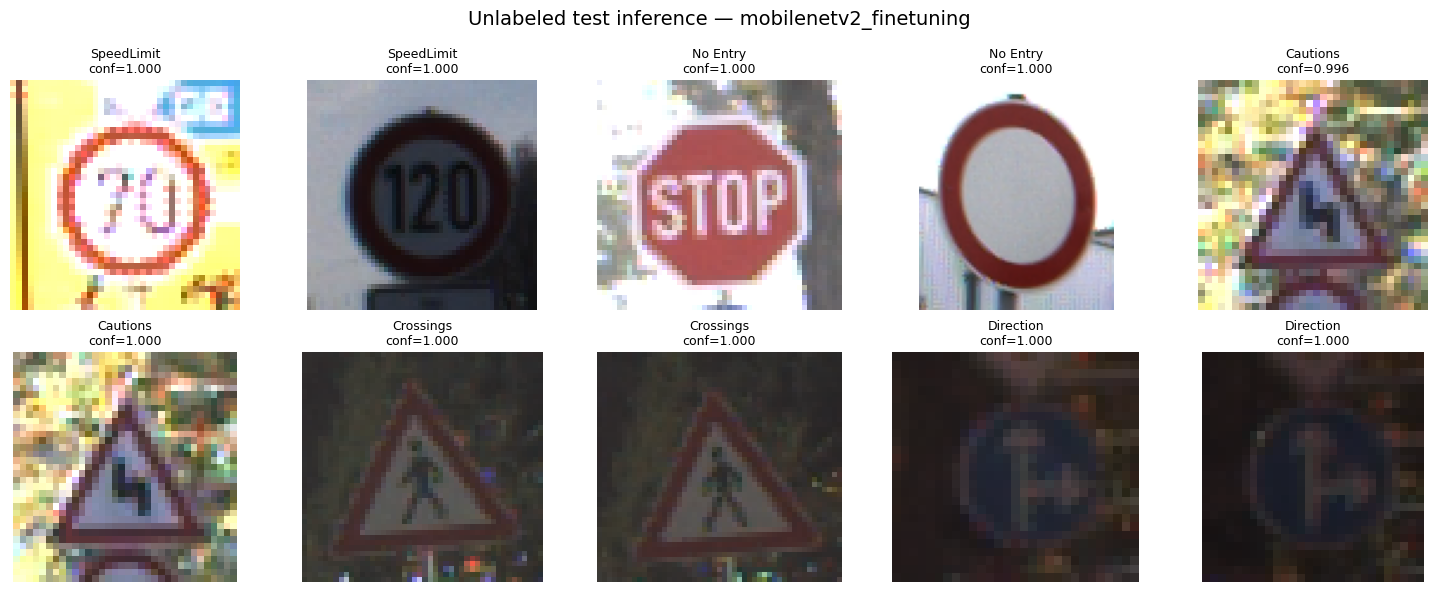

,path,filename,predicted_label_id,predicted_class,confidence
0,/home/wizard/Projects/school/AI/submissions/as...,00004_00002_00011.png,4,SpeedLimit,1.000000
1,/home/wizard/Projects/school/AI/submissions/as...,00008_00013_00018.png,4,SpeedLimit,1.000000
2,/home/wizard/Projects/school/AI/submissions/as...,00014_00000_00002.png,3,No Entry,1.000000
3,/home/wizard/Projects/school/AI/submissions/as...,00015_00002_00026.png,3,No Entry,1.000000
4,/home/wizard/Projects/school/AI/submissions/as...,00021_00000_00000.png,0,Cautions,0.995806


In [14]:
unlabeled_predictions = predict_unlabeled(
    qualitative["model"],
    unlabeled_df,
    id_to_label=id_to_label,
    use_transfer_pipeline=qualitative_name.startswith("mobilenetv2"),
)
unlabeled_predictions.to_csv(VISION.predictions / "unlabeled_test_predictions.csv", index=False)
show_unlabeled_predictions(
    unlabeled_predictions,
    path=VISION.figures / "inference_examples" / "unlabeled_test_inference_gallery.png",
    title=f"Unlabeled test inference — {qualitative_name}",
)
unlabeled_predictions.head()
